In [2]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
COLUNAS_REMOCAO = ["FID", "PAT", "MAT", "SEX", "PHENOTYPE"]

In [4]:
fenotipo = pd.read_csv('banco_fenotipos_conformal.csv')
caminho = ('Banco Genetico Imputado LD')
df_completo = None
for arquivo in os.listdir(caminho):
    if arquivo.endswith('.raw'):
        df_gen = pd.read_csv(f'{caminho}/{arquivo}',sep='\s+')
        df_gen = df_gen.drop(columns=COLUNAS_REMOCAO)
        if df_completo is None:
            df_completo = df_gen
        else:
            df_completo = pd.merge(left=df_completo,right=df_gen,on='IID',how='inner')

df_final = pd.merge(left=fenotipo,right=df_completo,left_on='samplefilename',right_on='IID',how='inner')
df_final = df_final.dropna(subset=['glicose_mg_dl'])

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10028\3003404813.py:6: SyntaxWarning: invalid escape sequence '\s'
  df_gen = pd.read_csv(f'{caminho}/{arquivo}',sep='\s+')


In [17]:
np.random.seed(67)
colunas_para_ignorar = ['glicose_mg_dl', 'IID', 'samplefilename','diabetes2','HOMA_IR','medDM_bioq']

# O errors='ignore' evita que o código quebre se alguma dessas 
# colunas já não existir mais no banco
X = df_final.drop(columns=colunas_para_ignorar, errors='ignore')
y = df_final['glicose_mg_dl']

In [18]:
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']

# 3. A MÁGICA DA TRADUÇÃO (One-Hot Encoding)
# drop_first=True evita redundância matemática. dtype=int garante que saia 0 e 1 em vez de True/False.
X_arrumado = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True, dtype=int)

In [19]:
# ==========================================
# 3. DIVIDINDO EM TREINO E TESTE
# ==========================================
# Separamos 80% dos indivíduos para o modelo "aprender" (treino)
# e 20% para testarmos se ele aprendeu bem com dados inéditos (teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(X_arrumado, y, test_size=0.2, random_state=67)

In [20]:
# ==========================================
# 4. CRIANDO E TREINANDO O MODELO
# ==========================================
# n_estimators=500 significa que ele vai criar 500 árvores de decisão
modelo_rf = RandomForestRegressor(n_estimators=200, random_state=67, n_jobs=5, max_features=0.1, oob_score=True)

# O comando .fit() é onde a mágica acontece. O modelo aprende a relação
# entre a genética/clínica (X) e o fenótipo (y).
modelo_rf.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
# ==========================================
# 5. TESTANDO O MODELO (PREVISÕES)
# ==========================================
# Agora pedimos para ele prever o desfecho dos 20% separados para teste
previsoes = modelo_rf.predict(X_teste)

In [22]:
# ==========================================
# 6. AVALIANDO O DESEMPENHO
# ==========================================
# Comparamos as previsões que o modelo fez com os valores reais (y_teste)
mse = mean_squared_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.2f}")
print(f"OOB Score (R² estimado): {modelo_rf.oob_score_:.4f}")

Erro Quadrático Médio (MSE): 1335.05
R² (Coeficiente de Determinação): 0.06
OOB Score (R² estimado): 0.0270


In [25]:
# Pega as importâncias matemáticas do modelo
importancias = modelo_rf.feature_importances_

# Pega o nome das 244 mil colunas do seu X
nomes_variaveis = X_treino.columns

# Cria uma tabela bonita ligando o nome ao valor de importância
tabela_importancia = pd.DataFrame({
    'Variavel': nomes_variaveis,
    'Importancia': importancias
})
top_20 = tabela_importancia.sort_values(by='Importancia', ascending=False).head(100)
print(top_20)

            Variavel  Importancia
5                imc     0.012269
112487   rs6040200_C     0.009295
126979  rs34533032_G     0.009018
3              idade     0.008901
10               ccm     0.008070
...              ...          ...
240945   rs7847257_C     0.001917
37783   rs17059611_C     0.001908
184570  rs79584746_A     0.001897
5139    rs16906223_C     0.001852
15528     rs292433_A     0.001830

[100 rows x 2 columns]


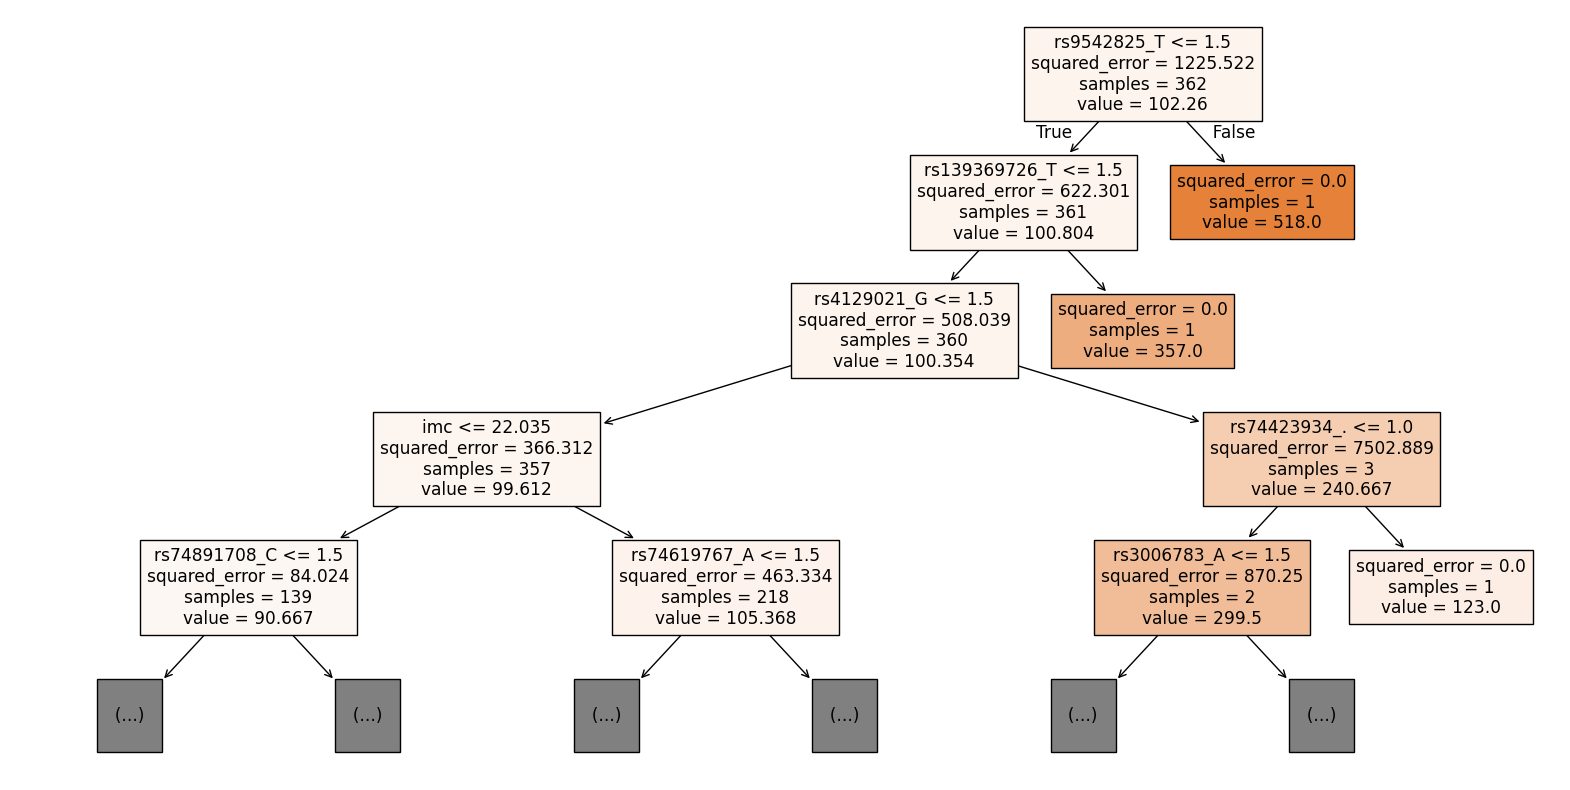

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plotar a primeira árvore do Random Forest
plt.figure(figsize=(20,10))
plot_tree(modelo_rf.estimators_[1], feature_names=X_treino.columns, filled=True, max_depth=4)
plt.show()